## Implementing logistic regression on virat kohli's dataset

In [78]:
import pandas as pd
df=pd.read_csv("goat.csv")
df.head()

,Score,Out/Not Out,Against,Batting Order,Inn.,Strike Rate,Venue,Column1,H/A,Date,Result,Format,Man of the Match,Captain,Unnamed: 14
0,116,Out,Australia,6,2,NaN,Adelaide Oval,Adelaide,Away,24-01-2012,Lost,Test,No,No,NaN
1,103,Out,New Zealand,5,2,NaN,M. Chinnaswamy Stadium,Bangalore,Home,31-08-2012,Won,Test,Yes,No,NaN
2,103,Out,England,5,2,NaN,Vidarbha Cricket Association Stadium,Nagpur,Home,13-12-2012,Drawn,Test,No,No,NaN
3,107,Out,Australia,5,2,NaN,M. A. Chidambaram Stadium,Chennai,Home,22-02-2013,Won,Test,No,No,NaN
4,119,Out,South Africa,4,1,NaN,Wanderers Stadium,Johannesburg,Away,18-12-2013,Drawn,Test,No,No,NaN


In [79]:
# Century is our target variable
# 1 = century
# 0 = no century

df["Century"] = (df["Score"] >= 100).astype(int)

# Check the result
df[["Score", "Century"]].head(10)

,Score,Century
0,116,1
1,103,1
2,103,1
3,107,1
4,119,1
5,105,1
6,115,1
7,141,1
8,169,1
9,147,1


In [80]:
X = df[["Result", "Venue"]]

y = df["Century"]

X.head()

,Result,Venue
0,Lost,Adelaide Oval
1,Won,M. Chinnaswamy Stadium
2,Drawn,Vidarbha Cricket Association Stadium
3,Won,M. A. Chidambaram Stadium
4,Drawn,Wanderers Stadium


In [81]:
df["Result"] = df["Result"].map({
    "Won": 1,
    "Lost": 0,
    "Drawn": 0
})

df["Result"].value_counts()

Result
1.0    48
0.0    20
Name: count, dtype: int64

In [82]:
print(df["Result"].unique())
print(df["Venue"].unique())

[ 0.  1. nan]
<StringArray>
[                               'Adelaide Oval',
                       'M. Chinnaswamy Stadium',
         'Vidarbha Cricket Association Stadium',
                    'M. A. Chidambaram Stadium',
                            'Wanderers Stadium',
                                'Basin Reserve',
                     'Melbourne Cricket Ground',
                        'Sydney Cricket Ground',
                  'Galle International Stadium',
                  'Sir Vivian Richards Stadium',
                               'Holkar Stadium',
                     'ACA-VDCA Cricket Stadium',
                             'Wankhede Stadium',
   'Rajiv Gandhi International Cricket Stadium',
                                 'Eden Gardens',
                      'Feroz Shah Kotla Ground',
                              'SuperSport Park',
                     'Edgbaston Cricket Ground',
                                 'Trent Bridge',
       'Saurashtra Cricket Association St

In [83]:
X = df[["Result", "Venue"]]

y = df["Century"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Result                                 Venue
0     0.0                         Adelaide Oval
1     1.0                M. Chinnaswamy Stadium
2     0.0  Vidarbha Cricket Association Stadium
3     1.0             M. A. Chidambaram Stadium
4     0.0                     Wanderers Stadium

Target:
0    1
1    1
2    1
3    1
4    1
Name: Century, dtype: int64


In [84]:
X = X.values
y = y.values

print(X.shape)
print(y.shape)

(71, 2)
(71,)


In [85]:
import numpy as np

weights = np.zeros(X.shape[1])
bias = 0

print("Weights:", weights)
print("Bias:", bias)

Weights: [0. 0.]
Bias: 0


In [86]:
df["H/A"] = df["H/A"].map({
    "Home": 0,
    "Away": 1
})

X = df[["Result", "H/A"]].values

print(X[:10])

[[0. 1.]
 [1. 0.]
 [0. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [87]:
z = np.dot(X, weights) + bias

print(z[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [88]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

probabilities = sigmoid(z)

print(probabilities[:10])

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [89]:
loss = -np.mean(
    y * np.log(probabilities) +
    (1 - y) * np.log(1 - probabilities)
)

print("Loss:", loss)

Loss: nan


In [90]:
dw = np.dot(X.T, (probabilities - y)) / len(y)
db = np.mean(probabilities - y)

print("dw:", dw)
print("db:", db)

dw: [nan nan]
db: nan


In [91]:
learning_rate = 0.01

weights = weights - learning_rate * dw
bias = bias - learning_rate * db

print("Updated weights:", weights)
print("Updated bias:", bias)

Updated weights: [nan nan]
Updated bias: nan


In [92]:
epochs = 1000

for i in range(epochs):

    z = np.dot(X, weights) + bias
    probabilities = sigmoid(z)

    dw = np.dot(X.T, (probabilities - y)) / len(y)
    db = np.mean(probabilities - y)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

print("Final weights:", weights)
print("Final bias:", bias)

Final weights: [nan nan]
Final bias: nan


In [93]:
z = np.dot(X, weights) + bias

probabilities = sigmoid(z)

print(probabilities[:10])

[nan nan nan nan nan nan nan nan nan nan]


In [94]:
predictions = (probabilities >= 0.5).astype(int)

print(predictions[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [95]:
accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.0
Accuracy (%): 0.0


In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, predictions)

print(cm)

[[ 0  0]
 [71  0]]


In [97]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y, predictions)
recall = recall_score(y, predictions)
f1 = f1_score(y, predictions)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.0
Recall: 0.0
F1 Score: 0.0


C:\Users\jarhp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [98]:
result = 1
home_away = 0

z = np.dot([result, home_away], weights) + bias
probability = sigmoid(z)

print("Probability of Century:", probability)
print("Prediction:", int(probability >= 0.5))

Probability of Century: nan
Prediction: 0


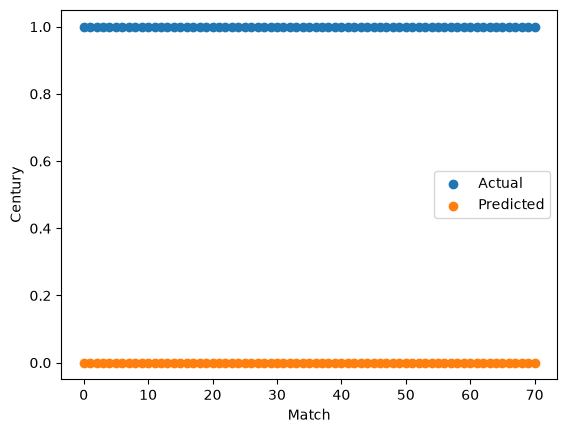

In [99]:
import matplotlib.pyplot as plt

plt.scatter(range(len(y)), y, label="Actual")
plt.scatter(range(len(predictions)), predictions, label="Predicted")

plt.xlabel("Match")
plt.ylabel("Century")
plt.legend()
plt.show()

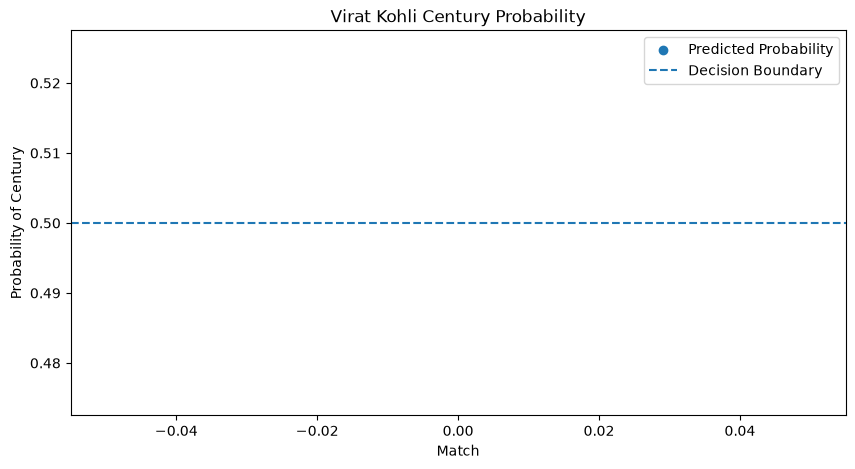

In [100]:
plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(probabilities)),
    probabilities,
    label="Predicted Probability"
)

plt.axhline(0.5, linestyle="--", label="Decision Boundary")

plt.xlabel("Match")
plt.ylabel("Probability of Century")
plt.title("Virat Kohli Century Probability")

plt.legend()
plt.show()

In [101]:
print("Result weight:", weights[0])
print("Home/Away weight:", weights[1])
print("Bias:", bias)

Result weight: nan
Home/Away weight: nan
Bias: nan


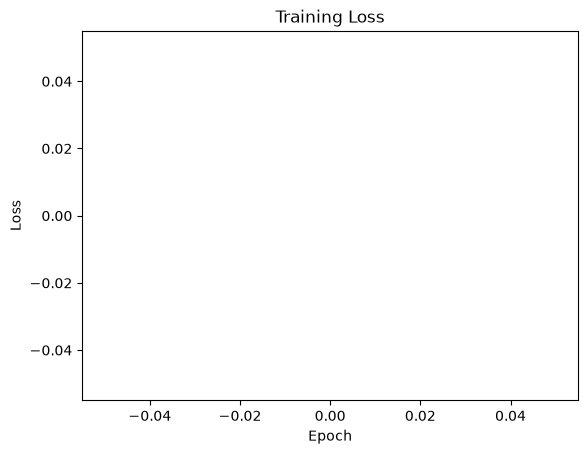

In [102]:
losses = []

for i in range(1000):
    z = np.dot(X, weights) + bias
    probabilities = sigmoid(z)

    loss = -np.mean(
        y * np.log(probabilities) +
        (1 - y) * np.log(1 - probabilities)
    )

    dw = np.dot(X.T, probabilities - y) / len(y)
    db = np.mean(probabilities - y)

    weights -= learning_rate * dw
    bias -= learning_rate * db

    losses.append(loss)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [103]:
results = pd.DataFrame({
    "Actual": y,
    "Probability": probabilities,
    "Predicted": predictions
})

results.head(20)

,Actual,Probability,Predicted
0,1,NaN,0
1,1,NaN,0
2,1,NaN,0
3,1,NaN,0
4,1,NaN,0
5,1,NaN,0
6,1,NaN,0
7,1,NaN,0
8,1,NaN,0
9,1,NaN,0


In [104]:
print("No Century:", np.sum(y == 0))
print("Century:", np.sum(y == 1))

print("Century percentage:", np.mean(y) * 100)

No Century: 0
Century: 71
Century percentage: 100.0


In [105]:
for i in range(10):
    print(
        f"Match {i+1}: "
        f"Actual={y[i]}, "
        f"Probability={probabilities[i]:.3f}, "
        f"Predicted={predictions[i]}"
    )

Match 1: Actual=1, Probability=nan, Predicted=0
Match 2: Actual=1, Probability=nan, Predicted=0
Match 3: Actual=1, Probability=nan, Predicted=0
Match 4: Actual=1, Probability=nan, Predicted=0
Match 5: Actual=1, Probability=nan, Predicted=0
Match 6: Actual=1, Probability=nan, Predicted=0
Match 7: Actual=1, Probability=nan, Predicted=0
Match 8: Actual=1, Probability=nan, Predicted=0
Match 9: Actual=1, Probability=nan, Predicted=0
Match 10: Actual=1, Probability=nan, Predicted=0


In [106]:
model = {
    "weights": weights,
    "bias": bias
}

np.save("logistic_regression_model.npy", model)

print("Model saved successfully!")

Model saved successfully!


In [107]:
loaded_model = np.load(
    "logistic_regression_model.npy",
    allow_pickle=True
).item()

weights = loaded_model["weights"]
bias = loaded_model["bias"]

print("Weights:", weights)
print("Bias:", bias)

Weights: [nan nan]
Bias: nan


## Prediction function

In [108]:
def predict(result, home_away):

    z = np.dot([result, home_away], weights) + bias
    probability = sigmoid(z)

    prediction = int(probability >= 0.5)

    return probability, prediction

In [109]:
probability, prediction = predict(
    result=1,
    home_away=0
)

print("Probability:", probability)
print("Prediction:", prediction)

Probability: nan
Prediction: 0


In [110]:
print("Result values:")
print(df["Result"].value_counts(dropna=False))

print("\nH/A values:")
print(df["H/A"].value_counts(dropna=False))

Result values:
Result
1.0    48
0.0    20
NaN     3
Name: count, dtype: int64

H/A values:
H/A
1    39
0    32
Name: count, dtype: int64


In [111]:
print(df[df["Result"].isna()][["Score", "Result", "H/A"]])

    Score  Result  H/A
32    107     NaN    1
40    102     NaN    1
63    157     NaN    0


In [112]:
df = df.dropna(subset=["Result"]).copy()

print("Remaining rows:", len(df))
print("Missing Result:", df["Result"].isna().sum())

Remaining rows: 68
Missing Result: 0


In [113]:
X = df[["Result", "H/A"]].values
y = df["Century"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (68, 2)
y shape: (68,)


In [114]:
weights = np.zeros(X.shape[1])
bias = 0

print("Weights:", weights)
print("Bias:", bias)

Weights: [0. 0.]
Bias: 0


In [115]:
epochs = 1000
learning_rate = 0.01

for i in range(epochs):
    z = np.dot(X, weights) + bias
    probabilities = sigmoid(z)

    dw = np.dot(X.T, probabilities - y) / len(y)
    db = np.mean(probabilities - y)

    weights -= learning_rate * dw
    bias -= learning_rate * db

print("Weights:", weights)
print("Bias:", bias)

Weights: [1.01410751 0.78290631]
Bias: 1.624183863265624


In [116]:
z = np.dot(X, weights) + bias

probabilities = sigmoid(z)

print(probabilities[:10])

[0.91736637 0.93328566 0.83537133 0.93328566 0.91736637 0.91736637
 0.91736637 0.91736637 0.91736637 0.91736637]


In [117]:
predictions = (probabilities >= 0.5).astype(int)

print(predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [118]:
accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


In [119]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, predictions)

print(cm)

[[68]]


C:\Users\jarhp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [120]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y, predictions)
recall = recall_score(y, predictions)
f1 = f1_score(y, predictions)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [121]:
result = 1
home_away = 0

probability, prediction = predict(
    result,
    home_away
)

print("Probability of Century:", probability)
print("Prediction:", prediction)

Probability of Century: 0.9332856582045205
Prediction: 1


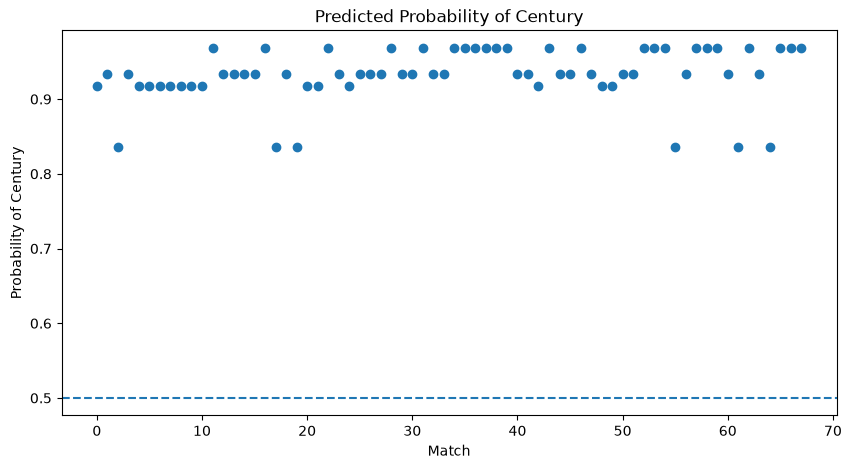

In [122]:
plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(probabilities)),
    probabilities
)

plt.axhline(0.5, linestyle="--")

plt.xlabel("Match")
plt.ylabel("Probability of Century")
plt.title("Predicted Probability of Century")

plt.show()

In [123]:
comparison = pd.DataFrame({
    "Actual": y,
    "Probability": probabilities,
    "Predicted": predictions
})

comparison.head(20)

,Actual,Probability,Predicted
0,1,0.917366,1
1,1,0.933286,1
2,1,0.835371,1
3,1,0.933286,1
4,1,0.917366,1
5,1,0.917366,1
6,1,0.917366,1
7,1,0.917366,1
8,1,0.917366,1
9,1,0.917366,1


In [124]:
comparison.to_csv(
    "logistic_regression_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


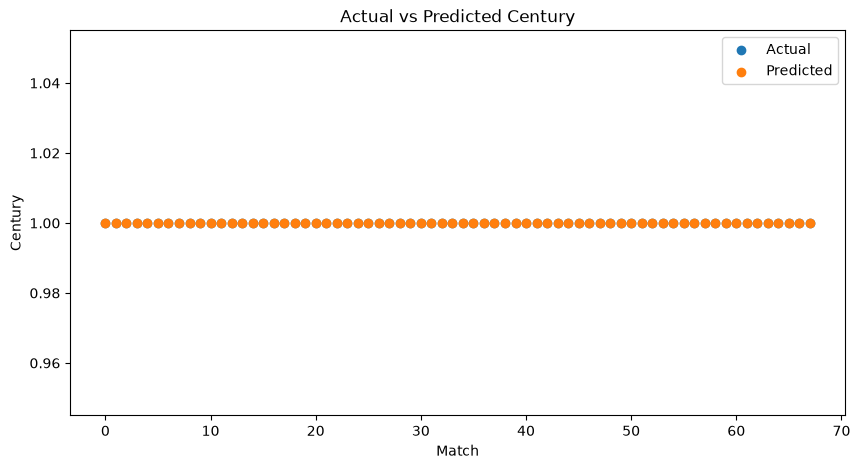

In [125]:
plt.figure(figsize=(10, 5))

plt.scatter(range(len(y)), y, label="Actual")
plt.scatter(range(len(predictions)), predictions, label="Predicted")

plt.xlabel("Match")
plt.ylabel("Century")
plt.title("Actual vs Predicted Century")

plt.legend()
plt.show()

In [126]:
print("Result weight:", weights[0])
print("Home/Away weight:", weights[1])
print("Bias:", bias)

Result weight: 1.0141075131990551
Home/Away weight: 0.7829063146155468
Bias: 1.624183863265624


In [127]:
loss = -np.mean(
    y * np.log(probabilities) +
    (1 - y) * np.log(1 - probabilities)
)

print("Final Loss:", loss)

Final Loss: 0.06988704717120318


In [128]:
model = {
    "weights": weights,
    "bias": bias
}

np.save(
    "virat_logistic_regression_model.npy",
    model
)

print("Final model saved!")

Final model saved!


In [129]:
loaded_model = np.load(
    "virat_logistic_regression_model.npy",
    allow_pickle=True
).item()

weights = loaded_model["weights"]
bias = loaded_model["bias"]

print("Model loaded successfully!")
print("Weights:", weights)
print("Bias:", bias)

Model loaded successfully!
Weights: [1.01410751 0.78290631]
Bias: 1.624183863265624


In [130]:
def predict_century(result, home_away):
    z = np.dot([result, home_away], weights) + bias
    probability = sigmoid(z)

    return probability, int(probability >= 0.5)

In [131]:
probability, prediction = predict_century(
    result=1,
    home_away=0
)

print("Probability of Century:", probability)
print("Prediction:", prediction)

Probability of Century: 0.9332856582045205
Prediction: 1


In [132]:
for i in range(10):
    print(
        f"Match {i + 1}: "
        f"Actual = {y[i]}, "
        f"Probability = {probabilities[i]:.3f}, "
        f"Predicted = {predictions[i]}"
    )

Match 1: Actual = 1, Probability = 0.917, Predicted = 1
Match 2: Actual = 1, Probability = 0.933, Predicted = 1
Match 3: Actual = 1, Probability = 0.835, Predicted = 1
Match 4: Actual = 1, Probability = 0.933, Predicted = 1
Match 5: Actual = 1, Probability = 0.917, Predicted = 1
Match 6: Actual = 1, Probability = 0.917, Predicted = 1
Match 7: Actual = 1, Probability = 0.917, Predicted = 1
Match 8: Actual = 1, Probability = 0.917, Predicted = 1
Match 9: Actual = 1, Probability = 0.917, Predicted = 1
Match 10: Actual = 1, Probability = 0.917, Predicted = 1


In [133]:
print("Correct predictions:", np.sum(predictions == y))
print("Wrong predictions:", np.sum(predictions != y))

print("Total matches:", len(y))
print("Accuracy:", np.mean(predictions == y))

Correct predictions: 68
Wrong predictions: 0
Total matches: 68
Accuracy: 1.0


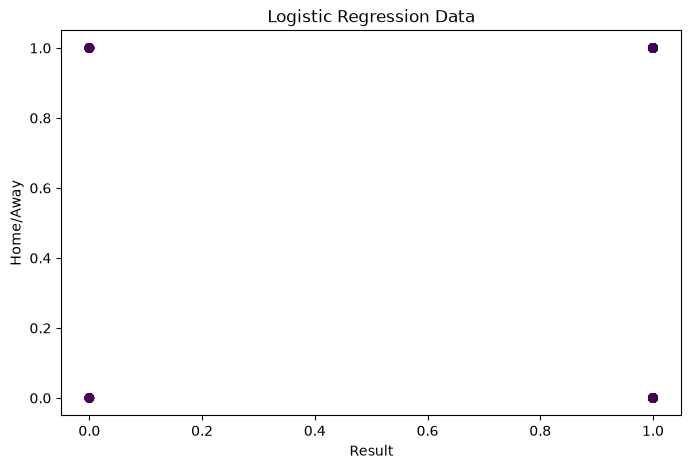

In [134]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("Result")
plt.ylabel("Home/Away")
plt.title("Logistic Regression Data")

plt.show()

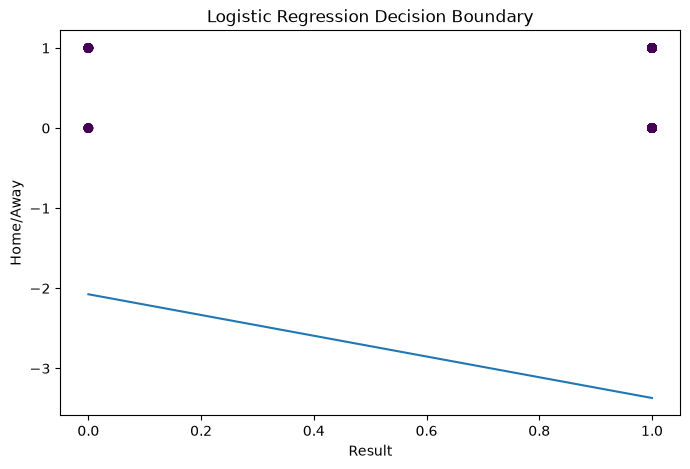

In [135]:
x_values = np.linspace(
    X[:, 0].min(),
    X[:, 0].max(),
    100
)

y_values = -(weights[0] * x_values + bias) / weights[1]

plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot(x_values, y_values)

plt.xlabel("Result")
plt.ylabel("Home/Away")
plt.title("Logistic Regression Decision Boundary")

plt.show()

C:\Users\jarhp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


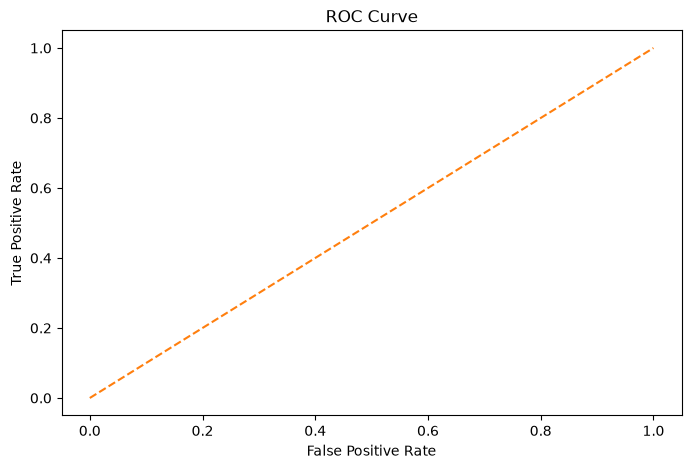

In [136]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y, probabilities)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [137]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y, probabilities)

print("ROC-AUC:", auc)

ROC-AUC: nan


C:\Users\jarhp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


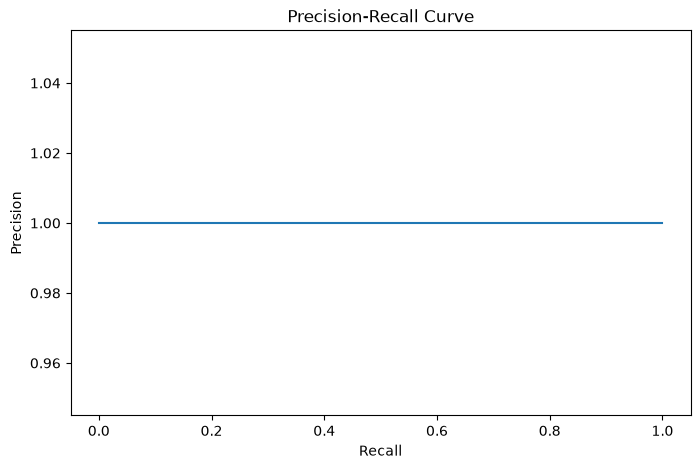

In [138]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y,
    probabilities
)

plt.figure(figsize=(8, 5))

plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [139]:
from sklearn.metrics import auc

pr_auc = auc(
    recall_curve,
    precision_curve
)

print("PR-AUC:", pr_auc)

PR-AUC: 1.0


In [140]:
class_counts = df["Century"].value_counts()

print(class_counts)
print("\nClass proportions:")
print(df["Century"].value_counts(normalize=True))

Century
1    68
Name: count, dtype: int64

Class proportions:
Century
1    1.0
Name: proportion, dtype: float64


In [141]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head()

,Score,Out/Not Out,Against,Batting Order,Inn.,Strike Rate,Venue,Column1,H/A,Date,Result,Format,Man of the Match,Captain,Unnamed: 14,Century
0,107,Out,Pakistan,3,1,84.90,Adelaide Oval,Adelaide,1,15-02-2015,1.0,ODI,Yes,No,NaN,1
1,103,Not Out,Sri Lanka,4,3,NaN,Galle International Stadium,Galle,1,26-07-2017,1.0,Test,No,Yes,NaN,1
2,119,Out,South Africa,4,1,NaN,Wanderers Stadium,Johannesburg,1,18-12-2013,0.0,Test,No,No,NaN,1
3,147,Out,Australia,4,2,NaN,Sydney Cricket Ground,Sydney,1,06-01-2015,0.0,Test,No,Yes,NaN,1
4,102,Not Out,Bangladesh,3,2,107.37,Sher-e-Bangla Cricket Stadium,Dhaka,1,11-01-2010,1.0,ODI,Yes,No,NaN,1


In [142]:
from sklearn.model_selection import train_test_split

X = df[["Result", "H/A"]].values
y = df["Century"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (54, 2)
Testing data: (14, 2)


In [143]:
weights = np.zeros(X_train.shape[1])
bias = 0

print("Weights:", weights)
print("Bias:", bias)

Weights: [0. 0.]
Bias: 0


In [144]:
epochs = 1000
learning_rate = 0.01

for i in range(epochs):
    z = np.dot(X_train, weights) + bias
    probabilities = sigmoid(z)

    dw = np.dot(X_train.T, probabilities - y_train) / len(y_train)
    db = np.mean(probabilities - y_train)

    weights -= learning_rate * dw
    bias -= learning_rate * db

print("Weights:", weights)
print("Bias:", bias)

Weights: [0.93606953 0.82988027]
Bias: 1.6540639084521414


In [145]:
z_test = np.dot(X_test, weights) + bias

probabilities_test = sigmoid(z_test)

predictions_test = (
    probabilities_test >= 0.5
).astype(int)

print(predictions_test)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [146]:
test_accuracy = np.mean(
    predictions_test == y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 1.0
Test Accuracy (%): 100.0


In [147]:
cm_test = confusion_matrix(
    y_test,
    predictions_test
)

print(cm_test)

[[14]]


C:\Users\jarhp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [148]:
test_precision = precision_score(y_test, predictions_test)
test_recall = recall_score(y_test, predictions_test)
test_f1 = f1_score(y_test, predictions_test)

print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", test_f1)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


C:\Users\jarhp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


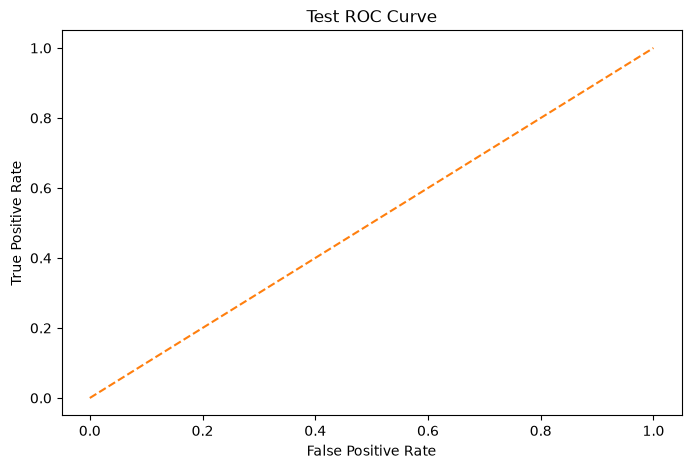

In [149]:


fpr_test, tpr_test, thresholds_test = roc_curve(
    y_test,
    probabilities_test
)

plt.figure(figsize=(8, 5))
plt.plot(fpr_test, tpr_test)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")

plt.show()

In [150]:


test_results = pd.DataFrame({
    "Actual": y_test,
    "Probability": probabilities_test,
    "Predicted": predictions_test
})

test_results

,Actual,Probability,Predicted
0,1,0.968324,1
1,1,0.923009,1
2,1,0.968324,1
3,1,0.930224,1
4,1,0.930224,1
5,1,0.968324,1
6,1,0.968324,1
7,1,0.930224,1
8,1,0.930224,1
9,1,0.930224,1


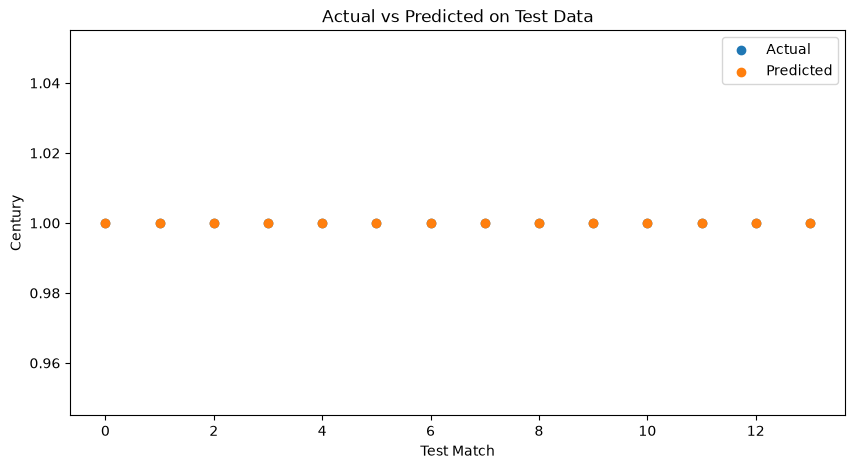

In [151]:


plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual"
)

plt.scatter(
    range(len(predictions_test)),
    predictions_test,
    label="Predicted"
)

plt.xlabel("Test Match")
plt.ylabel("Century")
plt.title("Actual vs Predicted on Test Data")

plt.legend()
plt.show()

In [155]:
# Cell 80 — Final Prediction Function

def predict_century(result, home_away):
    z = np.dot([result, home_away], weights) + bias
    probability = sigmoid(z)

    prediction = int(probability >= 0.5)

    return probability, prediction


probability, prediction = predict_century(1, 0)

print("Probability:", probability)
print("Prediction:", prediction)

Probability: 0.9302238789144874
Prediction: 1
